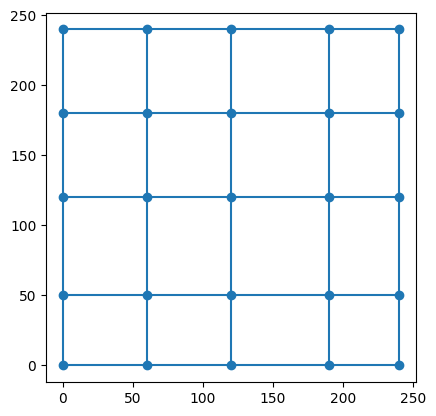

In [2]:
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon, box
import geopandas as gpd
from geopandas import GeoSeries, GeoDataFrame
from shapely.ops import split, unary_union, polygonize
import pickle
import osmnx as ox


# ### aggregate function from main roads

# In[2]:


def aggregate(lines):
    line = lines[0]
    for var in range(1, len(lines)):
        line = split(line, lines[var])
        if len(line.geoms) > 1:
            line = MultiLineString(line)
        else:
            line = line.geoms[0]
        new_line = split(lines[var], line)
        if len(new_line.geoms) > 1:
            new_line = MultiLineString(new_line)
        else:
            new_line = new_line.geoms[0]
        line = line.union(new_line)
    roads = list(line.geoms)
    roads_type = [2 for _ in range(len(roads))]
    intersections = []
    for road in roads:
        intersections.append(Point(road.coords[0]))
        intersections.append(Point(road.coords[1]))
    intersections = list(unary_union(intersections).geoms)
    intersections_type = [13 for _ in range(len(intersections))]
    feasibles = list(polygonize(roads))
    feasibles_type = [1 for _ in range(len(feasibles))]
    types = roads_type + intersections_type + feasibles_type
    geometries = roads + intersections + feasibles
    gdf = GeoDataFrame({'id': list(range(len(types))),
                        'type': types,
                        'existence': [True for _ in range(len(types))],
                        'geometry': geometries}).set_index('id')
    return gdf


# ## synthetic

# ### grid

# In[26]:


z = [LineString([(0, 0), (0, 240)]),
     LineString([(0, 240), (240, 240)]),
     LineString([(240, 240), (240, 0)]),
     LineString([(240, 0), (0, 0)]),
     LineString([(0, 120), (240, 120)]),
     LineString([(120, 0), (120, 240)]),
     LineString([(60, 0), (60, 240)]),
     LineString([(190, 0), (190, 240)]),
     LineString([(0, 50), (240, 50)]),
     LineString([(0, 180), (240, 180)])
    ]


# In[27]:


gdf = aggregate(z)


# In[28]:


gdf


# In[29]:


gdf[gdf.geom_type!='Polygon'].plot()


# In[30]:


d = dict()
d['gdf'] = gdf
with open('./g1.pickle', 'wb') as f:
    pickle.dump(d, f)



In [30]:
# ### hlg

# #### road + land_use

# In[138]:


z = [LineString([(442340, 4435700), (442720, 4435700)]), # 同成街
     LineString([(442720, 4435700), (443180, 4435700)]), # 同成街
     LineString([(443180, 4435700), (443600, 4435700)]), # 同成街
     LineString([(443600, 4435700), (444060, 4435700)]), # 同成街
     
     LineString([(441900, 4437560), (442000, 4437240)]), # 育知路
     LineString([(442000, 4437240), (442120, 4436880)]), # 育知路
     LineString([(442120, 4436880), (442240, 4436480)]), # 育知路
     LineString([(442240, 4436480), (442300, 4436160)]), # 育知路
     LineString([(442300, 4436160), (442340, 4435700)]), # 育知路
     
     LineString([(441900, 4437560), (442440, 4437650)]), # 回南北路
     LineString([(442440, 4437650), (442980, 4437740)]), # 回南北路
     LineString([(442980, 4437740), (443500, 4437740)]), # 回南北路
     LineString([(443500, 4437740), (443960, 4437740)]), # 回南北路
     
     LineString([(443960, 4437740), (443980, 4437400)]), # 文华东路
     LineString([(443980, 4437400), (444000, 4437060)]), # 文华东路
     LineString([(444000, 4437060), (444060, 4436720)]), # 文华东路
     LineString([(444060, 4436720), (444060, 4436200)]), # 文华东路
     LineString([(444060, 4436200), (444060, 4435700)]), # 文华东路
     
     LineString([(442240, 4436480), (442650, 4436630)]), # 回龙观西大街
     LineString([(442650, 4436630), (443100, 4436720)]), # 回龙观西大街
     LineString([(443100, 4436720), (443560, 4436720)]), # 回龙观西大街
     LineString([(443560, 4436720), (444060, 4436720)]), # 回龙观东大街
     
     LineString([(442440, 4437650), (442510, 4437310)]), # 育知东路
     LineString([(442510, 4437310), (442580, 4436970)]), # 育知东路
     LineString([(442580, 4436970), (442650, 4436630)]), # 育知东路
     LineString([(442650, 4436630), (442720, 4436200)]), # 育知东路
     LineString([(442720, 4436200), (442720, 4435700)]), # 育知东路
     
     LineString([(442980, 4437740), (443020, 4437400)]), # 文华西路
     LineString([(443020, 4437400), (443060, 4437060)]), # 文华西路
     LineString([(443060, 4437060), (443100, 4436720)]), # 文华西路
     LineString([(443100, 4436720), (443180, 4436200)]), # 文华西路
     LineString([(443180, 4436200), (443180, 4435700)]), # 文华西路
     
     LineString([(443500, 4437740), (443520, 4437400)]), # 文华路
     LineString([(443520, 4437400), (443540, 4437060)]), # 文华路
     LineString([(443540, 4437060), (443560, 4436720)]), # 文华路
     LineString([(443560, 4436720), (443600, 4436200)]), # 文华路
     LineString([(443600, 4436200), (443600, 4435700)]), # 文华路
     
     LineString([(442300, 4436160), (442720, 4436200)]), # 龙跃街
     LineString([(442720, 4436200), (443180, 4436200)]), # 龙跃街
     LineString([(443180, 4436200), (443600, 4436200)]), # 龙跃街
     LineString([(443600, 4436200), (444060, 4436200)]), # 龙跃街
     
     LineString([(442000, 4437240), (442510, 4437310)]), # 龙禧二街
     LineString([(442510, 4437310), (443020, 4437400)]), # 龙禧二街
     LineString([(443020, 4437400), (443520, 4437400)]), # 龙禧二街
     LineString([(443520, 4437400), (443980, 4437400)]), # 龙禧二街
     
     LineString([(442120, 4436880), (442580, 4436970)]), # 龙禧三街
     LineString([(442580, 4436970), (443060, 4437060)]), # 龙禧三街
     LineString([(443060, 4437060), (443540, 4437060)]), # 龙禧三街
     LineString([(443540, 4437060), (444000, 4437060)]), # 龙禧三街
     
     LineString([(442060, 4437060), (442302, 4437100)]), # 回龙园东侧空地
     LineString([(442255, 4437275), (442302, 4437100)]), # 云趣园二期西侧道路
     LineString([(442302, 4437100), (442350, 4436925)]), # 云趣园二期西侧道路
     
     LineString([(443400, 4437740), (443400, 4437400)]), # 禧乐汇
     
     LineString([(443525, 4437315), (443760, 4437315)]), # 回龙观镇医院
     LineString([(443760, 4437400), (443760, 4437315)]), # 回龙观镇医院
     
     LineString([(443535, 4437145), (443995, 4437145)]), # 爱蕾幼儿园
     
     LineString([(443050, 4437145), (443535, 4437145)]), # 幸福童心幼儿园
     
     LineString([(443555, 4436805), (444045, 4436805)]), # 龙泽园街道办事处
     
     LineString([(443090, 4436805), (443555, 4436805)]), # 回龙观法治文化公园
     
     LineString([(443568, 4436616), (444060, 4436616)]), # 腾讯众创空间
     
     LineString([(443830, 4436440), (444060, 4436440)]), # 昌平二中
     LineString([(443830, 4436440), (443830, 4436200)]), # 昌平二中
     
     LineString([(443400, 4436200), (443400, 4435950)]), # 龙腾苑四区改造
     LineString([(443400, 4435950), (443600, 4435950)]), # 龙腾苑四区改造
     
     LineString([(442720, 4435950), (443180, 4435950)]), # BHG华联购物中心
     
     LineString([(442320, 4435930), (442405, 4435930)]), # 幸福童年幼儿园
     LineString([(442405, 4436170), (442405, 4435930)]), # 幸福童年幼儿园
     
     LineString([(442255, 4436400), (442615, 4436400)]), # 港龙商业中心
     LineString([(442615, 4436400), (442615, 4436190)]), # 港龙商业中心
     LineString([(442615, 4436400), (442685, 4436415)]), # 北京安达医院
     
     LineString([(442685, 4436415), (442835, 4436415)]), # 昌平第二实验小学
     LineString([(442835, 4436415), (442835, 4436200)]), # 昌平第二实验小学
     
     LineString([(442664, 4436544), (443116, 4436616)]), # 上品折扣
     
     LineString([(442820, 4437015), (442859.5, 4436768.5)]), # 文华市场
     LineString([(442629, 4436732), (443090, 4436805)]), # 北店时代广场
     
     LineString([(442488, 4437140), (442545, 4437140)]), # 云趣园东南角
     LineString([(442488, 4437140), (442488, 4436952)]), # 云趣园东南角
     
    ]

In [31]:
# In[139]:


gdf = GeoDataFrame({'id': list(range(len(z))), 'geometry': z})
# define a bounding box in Beijing
north, south, east, west = 40.0887, 40.0698, 116.3444, 116.31852


In [32]:
# create network from that bounding box
bbox_tuple = (west, south, east, north)
G = ox.graph_from_bbox(bbox_tuple, network_type="drive")
G_projected = ox.project_graph(G)
#G = ox.graph_from_bbox(north, south, east, west, network_type="drive")
#G_projected = ox.project_graph(G)

In [33]:
gdf = gdf.set_crs(ox.graph_to_gdfs(G_projected)[1].crs)
gdf.explore()


<Axes: >

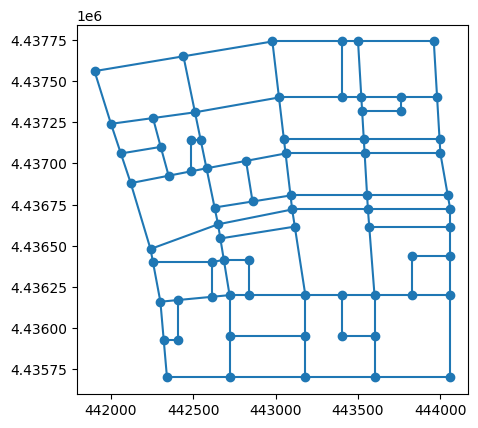

In [13]:
# In[140]:


gdf = aggregate(z)
gdf[gdf.geom_type!='Polygon'].plot()

In [14]:
# In[141]:


print(len(gdf[gdf.geom_type=='LineString']))
print(len(gdf[gdf.geom_type=='Point']))
print(len(gdf[gdf.geom_type=='Polygon']))


111
72
40


In [15]:
# In[142]:


gdf_roads = gdf[gdf.geom_type!='Polygon']
gdf_roads = gdf_roads.set_crs(ox.graph_to_gdfs(G_projected)[1].crs)
gdf_roads.explore()

In [16]:
# In[143]:


gdf = gdf.set_crs(ox.graph_to_gdfs(G_projected)[1].crs)
gdf.explore()

In [17]:
# In[144]:


residential_ids = [187, 194, 195, 197, 189, 209, 210, 217, 198, 190, 212, 220, 200, 192, 213, 203, 183, 216, 185, 186]
green_l_ids = [207]
gdf.loc[residential_ids, 'type'] = 4
gdf.loc[green_l_ids, 'type'] = 7

In [18]:
# In[145]:


minx, miny, _, _ = gdf.unary_union.bounds
print(minx, miny)
gdf['geometry'] = gdf['geometry'].translate(-minx, -miny)

441900.0 4435700.0


/tmp/ipykernel_2700660/3316722620.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  minx, miny, _, _ = gdf.unary_union.bounds


In [19]:
# In[146]:


print(gdf.area.sum())
print(gdf.unary_union.bounds)

3747400.0
(0.0, 0.0, 2160.0, 2040.0)


/tmp/ipykernel_2700660/2727470261.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  print(gdf.unary_union.bounds)


<Axes: >

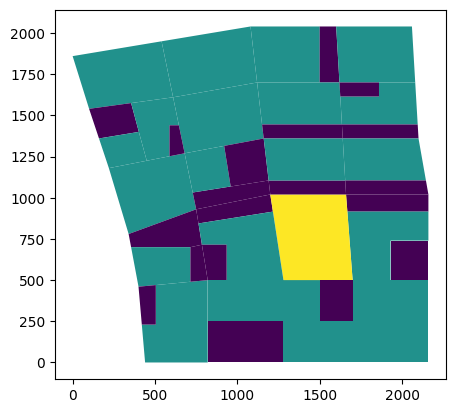

In [20]:
# In[147]:


gdf[gdf.geom_type=='Polygon'].plot('type')

In [21]:

# In[148]:


d = dict()
d['gdf'] = gdf
with open('./hlg.pickle', 'wb') as f:
    pickle.dump(d, f)

In [1]:
import geopandas as gpd
import pickle
import os
import argparse
from pathlib import Path

def geojson_to_pickle(input_file, output_file=None):
    """
    Convert a GeoJSON file to a pickle file
    
    Parameters:
    -----------
    input_file : str
        Path to the input GeoJSON file
    output_file : str, optional
        Path to the output pickle file. If None, will use the same name as input but with .pickle extension
    
    Returns:
    --------
    str
        Path to the output pickle file
    """
    # 确保输入文件存在
    if not os.path.exists(input_file):
        raise FileNotFoundError(f"Input file not found: {input_file}")
    
    # 如果未指定输出文件，创建默认名称
    if output_file is None:
        input_path = Path(input_file)
        output_file = str(input_path.with_suffix('.pickle'))
    
    # 读取GeoJSON文件
    print(f"Reading GeoJSON file: {input_file}")
    gdf = gpd.read_file(input_file)
    
    # 输出一些基本信息
    print(f"GeoDataFrame shape: {gdf.shape}")
    print(f"Geometry types: {gdf.geom_type.value_counts().to_dict()}")
    
    # 保存为pickle文件
    print(f"Saving to pickle file: {output_file}")
    with open(output_file, 'wb') as f:
        pickle.dump(gdf, f)
    
    print("Conversion completed successfully")
    return output_file

In [2]:
input_file = "g6.geojson"
output_file = "g6.pickle"

geojson_to_pickle(input_file, output_file)

Reading GeoJSON file: g6.geojson
GeoDataFrame shape: (324, 4)
Geometry types: {'Point': 144, 'LineString': 144, 'Polygon': 36}
Saving to pickle file: g6.pickle
Conversion completed successfully


'g6.pickle'